Original shape: (631193, 2)
Unique types:
 type
benign        428103
defacement     96457
phishing       74113
malware        32520
Name: count, dtype: int64
Filtered shape: (557080, 2)
Label mapping: {0: 'benign', 1: 'defacement', 2: 'malware'}
Extracting features...

Classification Report:
               precision    recall  f1-score   support

      benign       1.00      1.00      1.00     85621
  defacement       0.98      0.98      0.98     19291
     malware       0.93      0.93      0.93      6504

    accuracy                           0.99    111416
   macro avg       0.97      0.97      0.97    111416
weighted avg       0.99      0.99      0.99    111416



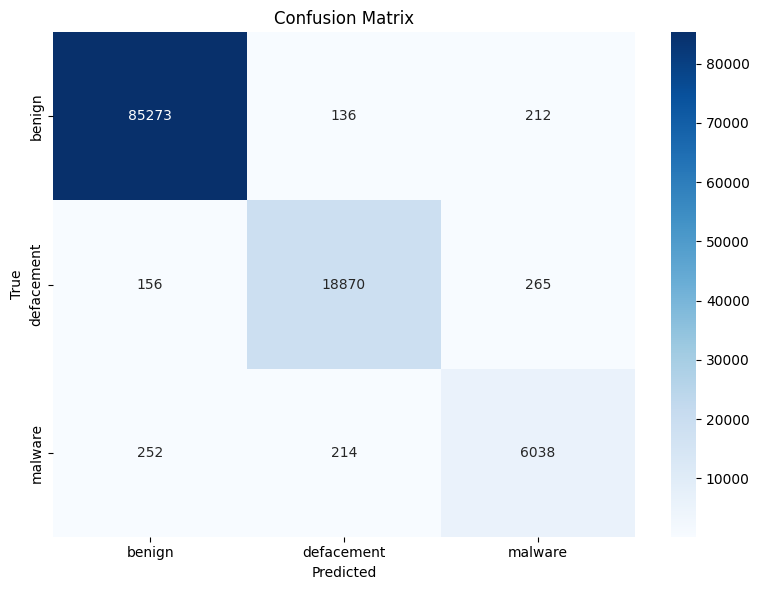

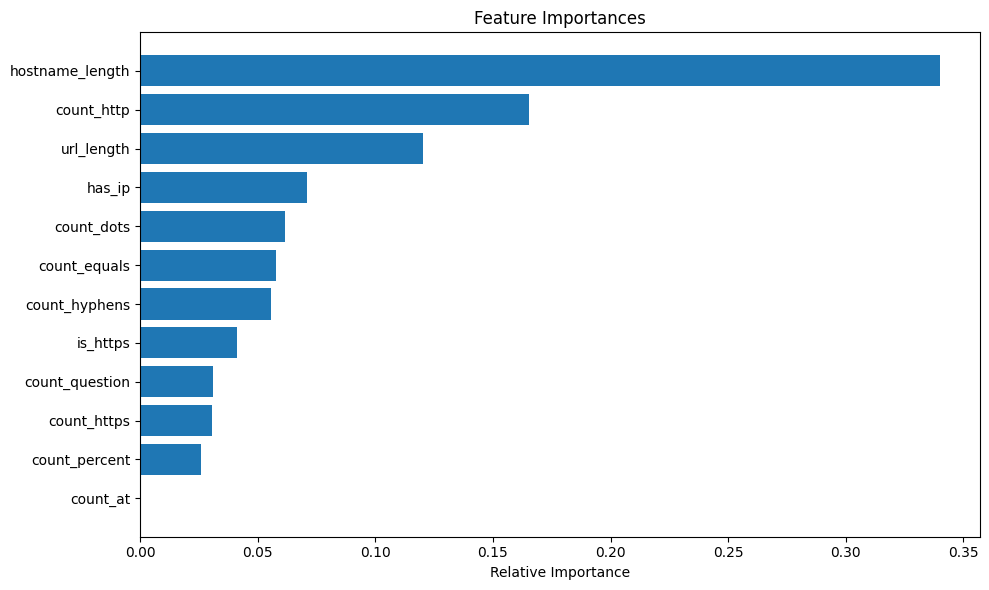


Prediction for http://malicious-phish.fakeupdate.com/index: malware


['URL_Flask/label_map.pkl']

In [ ]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------
# 1. Load Dataset
# --------------------------
df = pd.read_csv('malicious_phish.csv')
print("Original shape:", df.shape)
print("Unique types:\n", df['type'].value_counts())

# --------------------------
# 2. Filter Only Target Classes
# --------------------------
allowed_types = ['benign','malware', 'defacement']
df = df[df['type'].isin(allowed_types)]
print("Filtered shape:", df.shape)

# --------------------------
# 3. Encode Label as Categorical
# --------------------------
df['label'] = df['type'].astype('category').cat.codes
label_map = dict(enumerate(df['type'].astype('category').cat.categories))
print("Label mapping:", label_map)


# --------------------------
# 4. Feature Engineering
# --------------------------
def extract_features(url):
    parsed = urlparse(url)
    hostname = parsed.hostname if parsed.hostname else ""
    return {
        'url_length': len(url),
        'hostname_length': len(hostname),
        'count_dots': url.count('.'),
        'count_hyphens': url.count('-'),
        'count_at': url.count('@'),
        'count_question': url.count('?'),
        'count_percent': url.count('%'),
        'count_equals': url.count('='),
        'count_http': url.count('http'),
        'count_https': url.count('https'),
        'has_ip': 1 if re.match(r'^\d{1,3}(\.\d{1,3}){3}', hostname) else 0,
        'is_https': 1 if parsed.scheme == 'https' else 0
    }

print("Extracting features...")
features_df = df['url'].apply(lambda x: pd.Series(extract_features(x)))

# --------------------------
# 5. Prepare Features and Labels
# --------------------------
X = features_df
y = df['label']

# --------------------------
# 6. Train-Test Split
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --------------------------
# 7. Model Training
# --------------------------
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# --------------------------
# 8. Evaluation
# --------------------------
y_pred = model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_map.values()))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_map.values(), yticklabels=label_map.values(), cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# --------------------------
# 9. Feature Importance
# --------------------------
importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

# --------------------------
# 10. Predict on New URL
# --------------------------
def predict_url(url):
    feat = pd.DataFrame([extract_features(url)])
    pred = model.predict(feat)[0]
    return label_map[pred]

# Example
test_url = "http://malicious-phish.fakeupdate.com/index"
print(f"\nPrediction for {test_url}: {predict_url(test_url)}")


import joblib

# Save only the model
joblib.dump(model, "URL_Flask/randomforest.pkl")

# Save label_map separately
joblib.dump(label_map, "URL_Flask/label_map.pkl")
